# Piezo-Beam Torch FE Analysis (Differentiable)

This notebook mirrors the FE workflow using `Modeling.models_torch` instead of `Modeling.models.FE3`.

What this notebook provides:
- Differentiable assembly of reduced `K`, `M`, and `Gamma`
- Generalized eigen-analysis for natural frequencies
- Gradient extraction with respect to design/material parameters
- Modal FRF-style velocity estimate for frequency sweeps
- **Arbitrary region geometry** via `build_geometry_from_types`

The region API matches the FE3-style pattern: define `region_types`, `region_sequence`, and `x_starts`, then pass the resulting geometry into `PiezoBeamFE_Torch` as `geometry=...`.

In [12]:
import sys
import importlib
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Find workspace root containing Modeling/ and add to sys.path
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "Modeling").exists()), None)
if project_root is None:
    raise RuntimeError("Could not find workspace root containing Modeling/.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import Modeling.models_torch.beam_params_torch as bp_torch_mod
import Modeling.models_torch.fe_torch as fe_torch_mod
import Modeling.models_torch.fe_helpers_compat as compat_mod
from Modeling.models.beam_properties import PiezoBeamParams
import Modeling.models.FE3 as FE3_module
from Modeling.models import FE_helpers

importlib.reload(bp_torch_mod)
importlib.reload(fe_torch_mod)
importlib.reload(compat_mod)
importlib.reload(FE3_module)
importlib.reload(FE_helpers)

PiezoBeamParamsTorch = bp_torch_mod.PiezoBeamParamsTorch
PiezoBeamFE_Torch = fe_torch_mod.PiezoBeamFE_Torch
build_geometry_from_types = fe_torch_mod.build_geometry_from_types
build_ode_system_compat = compat_mod.build_ode_system_compat

torch.set_default_dtype(torch.float64)
print(f"Using project root: {project_root}")

Using project root: C:\Users\setemadi3\GaTech Dropbox\Seyednima Etemadi\Projects\Metamaterial beam


In [13]:
# ------------------------------------------------------------
# Parameter setup (aligned with the original FE3 notebook)
# and arbitrary region layout via build_geometry_from_types
# ------------------------------------------------------------
L = 0.3
b_s = 100e-3
b_p = 14e-3
b_k = 25e-3
h_s = 0.5e-3
h_p = 0.12e-3
h_k = 0.2e-3
rho_s = 1190.0
rho_p = 7800.0
rho_k = 1420.0
E_s = 3e9
E_p = 31e9
E_k = 3e9
d31 = -1.48e-10
eps_r = 1700.0

# Use the same modal damping dictionary as FE3 defaults
params_ref = PiezoBeamParams()
params_ref.zeta_p = 0.05
params_ref.zeta_q = 0.2
zeta_dict = dict(params_ref.zeta_dict)

def compute_EI_and_rhoA(E_layers, rho_layers, h_layers, b_layers):
    E_layers = np.asarray(E_layers, dtype=float)
    rho_layers = np.asarray(rho_layers, dtype=float)
    h_layers = np.asarray(h_layers, dtype=float)
    b_layers = np.asarray(b_layers, dtype=float)
    if not (len(E_layers) == len(rho_layers) == len(h_layers) == len(b_layers)):
        raise ValueError("Layer arrays must have the same length.")

    y = [h_layers[0] / 2]
    for i in range(1, len(h_layers)):
        y.append(y[i - 1] + h_layers[i])

    EI = 0.0
    rhoA = 0.0
    for i, (E, b) in enumerate(zip(E_layers, b_layers)):
        if i == 0:
            EI += E * b * y[i] ** 3 / 3.0
            rhoA += rho_layers[i] * b * h_layers[i] / 2.0
        else:
            EI += E * b * (y[i] ** 3 - y[i - 1] ** 3) / 3.0
            rhoA += rho_layers[i] * b * h_layers[i]
    return 2.0 * EI, 2.0 * rhoA

EI_kapton, rhoA_kapton = compute_EI_and_rhoA(
    E_layers=[E_s, E_k],
    rho_layers=[rho_s, rho_k],
    h_layers=[h_s, h_k],
    b_layers=[b_s, b_k],
)
EI_piezo, rhoA_piezo = compute_EI_and_rhoA(
    E_layers=[E_s, E_k, E_p],
    rho_layers=[rho_s, rho_k, rho_p],
    h_layers=[h_s, h_k, h_p],
    b_layers=[b_s, b_k, b_p],
)

rhoA_substrate = b_s * rho_s * h_s
EI_substrate = b_s * E_s * h_s ** 3 / 12.0

region_types = {
    "substrate": {"EI": EI_substrate, "rhoA": rhoA_substrate, "h": 1e-3},
    "piezo": {"EI": EI_piezo, "rhoA": rhoA_piezo, "h": 5e-3},
    "kapton": {"EI": EI_kapton, "rhoA": rhoA_kapton, "h": 1e-3},
}
region_sequence = [
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
    "kapton", "piezo", "kapton", "substrate",
]
unit_cell = np.array([0, 4.5, 32.5, 37.0]) * 1e-3
x_starts = np.concatenate([unit_cell + i * 40e-3 for i in range(5)])

geom = build_geometry_from_types(
    L=L,
    region_types=region_types,
    region_sequence=region_sequence,
    x_starts=x_starts,
    default_h=1e-3,
)

tp = PiezoBeamParamsTorch(dtype=torch.float64)
with torch.no_grad():
    tp.hp.copy_(torch.tensor(h_p, dtype=tp.hp.dtype))
    tp.hs.copy_(torch.tensor(h_s, dtype=tp.hs.dtype))
    tp.b.copy_(torch.tensor(b_s, dtype=tp.b.dtype))
    tp.E_s.copy_(torch.tensor(E_s, dtype=tp.E_s.dtype))
    tp.s11.copy_(torch.tensor(1.0 / E_p, dtype=tp.s11.dtype))
    tp.rho_s.copy_(torch.tensor(rho_s, dtype=tp.rho_s.dtype))
    tp.rho_p.copy_(torch.tensor(rho_p, dtype=tp.rho_p.dtype))
    tp.d31.copy_(torch.tensor(d31, dtype=tp.d31.dtype))
    tp.eps_r.copy_(torch.tensor(eps_r, dtype=tp.eps_r.dtype))

n_elem = len(geom.elem_EI)
x_nodes = np.asarray(geom.x_nodes, dtype=float)
x_mid = 0.5 * (x_nodes[:-1] + x_nodes[1:])

# Build per-element region labels to map differentiable properties by type
region_labels = []
x_starts_np = np.asarray(x_starts, dtype=float)
for xm in x_mid:
    idx = np.searchsorted(x_starts_np, xm, side="right") - 1
    idx = int(np.clip(idx, 0, len(region_sequence) - 1))
    region_labels.append(region_sequence[idx])

mask_sub = torch.tensor([lbl == "substrate" for lbl in region_labels], dtype=torch.bool)
mask_pie = torch.tensor([lbl == "piezo" for lbl in region_labels], dtype=torch.bool)
mask_kap = torch.tensor([lbl == "kapton" for lbl in region_labels], dtype=torch.bool)

# Constants for kapton-containing regions; gradients still flow through tp terms
E_k_t = torch.tensor(E_k, dtype=tp.dtype)
rho_k_t = torch.tensor(rho_k, dtype=tp.dtype)
b_k_t = torch.tensor(b_k, dtype=tp.dtype)
h_k_t = torch.tensor(h_k, dtype=tp.dtype)

def layered_EI_rhoA_torch(E_layers, rho_layers, h_layers, b_layers):
    y = [h_layers[0] / 2.0]
    for i in range(1, len(h_layers)):
        y.append(y[i - 1] + h_layers[i])

    EI = torch.zeros((), dtype=tp.dtype)
    rhoA = torch.zeros((), dtype=tp.dtype)
    for i, (E_i, b_i) in enumerate(zip(E_layers, b_layers)):
        if i == 0:
            EI = EI + E_i * b_i * y[i] ** 3 / 3.0
            rhoA = rhoA + rho_layers[i] * b_i * h_layers[i] / 2.0
        else:
            EI = EI + E_i * b_i * (y[i] ** 3 - y[i - 1] ** 3) / 3.0
            rhoA = rhoA + rho_layers[i] * b_i * h_layers[i]
    return 2.0 * EI, 2.0 * rhoA

def elem_property_fn(tp_local):
    E_p_t = 1.0 / tp_local.s11

    EI_sub = tp_local.b * tp_local.E_s * tp_local.hs ** 3 / 12.0
    rhoA_sub = tp_local.b * tp_local.rho_s * tp_local.hs

    EI_kap, rhoA_kap = layered_EI_rhoA_torch(
        E_layers=[tp_local.E_s, E_k_t],
        rho_layers=[tp_local.rho_s, rho_k_t],
        h_layers=[tp_local.hs, h_k_t],
        b_layers=[tp_local.b, b_k_t],
    )

    EI_pie, rhoA_pie = layered_EI_rhoA_torch(
        E_layers=[tp_local.E_s, E_k_t, E_p_t],
        rho_layers=[tp_local.rho_s, rho_k_t, tp_local.rho_p],
        h_layers=[tp_local.hs, h_k_t, tp_local.hp],
        b_layers=[tp_local.b, b_k_t, torch.tensor(b_p, dtype=tp_local.dtype)],
    )

    EI_vec = torch.empty((n_elem,), dtype=tp_local.dtype)
    rhoA_vec = torch.empty((n_elem,), dtype=tp_local.dtype)
    EI_vec = torch.where(mask_sub, EI_sub, EI_vec)
    rhoA_vec = torch.where(mask_sub, rhoA_sub, rhoA_vec)
    EI_vec = torch.where(mask_kap, EI_kap, EI_vec)
    rhoA_vec = torch.where(mask_kap, rhoA_kap, rhoA_vec)
    EI_vec = torch.where(mask_pie, EI_pie, EI_vec)
    rhoA_vec = torch.where(mask_pie, rhoA_pie, rhoA_vec)
    return EI_vec, rhoA_vec

fe = PiezoBeamFE_Torch(tp, geometry=geom, elem_property_fn=elem_property_fn)
n_piezos = len(fe._mesh.piezo_node_pairs)

print("Torch FE model built (arbitrary regions + differentiable EI/rhoA).")
print(f"  n_elem:  {len(geom.elem_EI)}")
print(f"  Ndof:    {fe.K_hat.shape[1]}")
print(f"  Nfree:   {len(fe._mesh.free_dofs)}")
print(f"  S:       {n_piezos}")
print(f"  L from geometry: {geom.x_nodes[-1]:.4f} m")
print(f"zeta_dict['rest'] = {zeta_dict.get('rest')}")

Torch FE model built (arbitrary regions + differentiable EI/rhoA).
  n_elem:  199
  Ndof:    400
  Nfree:   398
  S:       5
  L from geometry: 0.3000 m
zeta_dict['rest'] = 0.4


In [4]:
# ------------------------------------------------------------
# Assemble differentiable matrices and run modal analysis
# ------------------------------------------------------------
K_red, M_red, Gamma_red = fe.build_KM_Gamma()
out = fe(n_modes=20)

freq = out['freq'].detach().cpu().numpy()

print("Shapes:")
print(f"  K_red:    {tuple(K_red.shape)}")
print(f"  M_red:    {tuple(M_red.shape)}")
print(f"  Gamma_red:{tuple(Gamma_red.shape)}")

print("\nFirst 10 natural frequencies [Hz]:")
for i, f_i in enumerate(freq[:10], start=1):
    print(f"  Mode {i:2d}: {f_i:10.4f}")

Shapes:
  K_red:    (398, 398)
  M_red:    (398, 398)
  Gamma_red:(398, 5)

First 10 natural frequencies [Hz]:
  Mode  1:     2.8282
  Mode  2:    13.5287
  Mode  3:    33.7419
  Mode  4:    69.8994
  Mode  5:   109.5693
  Mode  6:   165.0307
  Mode  7:   231.6505
  Mode  8:   281.0672
  Mode  9:   427.6873
  Mode 10:   593.2645


In [14]:
# ------------------------------------------------------------
# FRF comparison: FE3 vs fe_torch-compat with same parameters
# ------------------------------------------------------------
j_exc = np.arange(n_piezos)
phase_exc = np.array([np.pi / 4] * n_piezos)
A_exc = np.ones(n_piezos)
weights_complex = A_exc * np.exp(1j * phase_exc)

f0, f1, n_freq = 0.1, 50.0, 500
freq_fd = np.linspace(f0, f1, n_freq)
omega_fd = 2.0 * np.pi * freq_fd

def v_exc(t):
    t_arr = np.asarray(t)
    phi = 2.0 * np.pi * (f0 + t_arr * (f1 - f0) / 1.0) * t_arr
    vals = A_exc[:, None] * np.sin(phi[None, :] + phase_exc[:, None]) if t_arr.ndim > 0 else A_exc * np.sin(phi + phase_exc)
    return vals

# ---- fe_torch through FE_helpers compatibility wrapper ----
ode_torch = build_ode_system_compat(
    fe=fe,
    j_exc=j_exc,
    R_c=1e3,
    K_p=0.0,
    K_i=0.0,
    K_c=0.0,
    v_exc=v_exc,
    freq_domain_amps=weights_complex,
    c_alpha=0.0,
    c_beta=0.0,
    zeta_dict=zeta_dict,
)
frf_torch = FE_helpers.frf_sweep(ode_torch, omega_fd)
vel_fd_torch = np.mean(np.abs(frf_torch['u_dot']), axis=1)

# ---- FE3 model with the same geometry/properties and same zeta_dict ----
params_fe3 = PiezoBeamParams(
    b=b_s,
    hp=h_p,
    hs=h_s,
    rho_s=rho_s,
    rho_p=rho_p,
    E_s=E_s,
    s11=1.0 / E_p,
    d31=d31,
    eps_r=eps_r,
    omega_p=2 * np.pi * 1,
    omega_q=2 * np.pi * 100,
)
params_fe3.zeta_p = 0.05
params_fe3.zeta_q = 0.2
params_fe3.zeta_dict = dict(zeta_dict)
params_fe3.c_alpha = 0.0
params_fe3.c_beta = 0.0

geom_fe3 = FE3_module.build_geometry_from_types(
    L=L,
    region_types=region_types,
    region_sequence=region_sequence,
    x_starts=x_starts,
)
params_fe3.geometry = geom_fe3
fe3 = FE3_module.PiezoBeamFE(params_fe3)

ode_fe3 = fe3.build_ode_system(
    j_exc=j_exc,
    R_c=1e3,
    K_p=0.0,
    K_i=0.0,
    K_c=0.0,
    v_exc=v_exc,
    freq_domain_amps=weights_complex,
)
frf_fe3 = FE_helpers.frf_sweep(ode_fe3, omega_fd)
vel_fd_fe3 = np.mean(np.abs(frf_fe3['u_dot']), axis=1)

# keep previous variable name for downstream cells
vel_fd = vel_fd_torch

ratio = vel_fd_fe3 / (vel_fd_torch + 1e-30)
print("FRF sweeps finished with shared settings.")
print(f"  zeta_dict['rest'] = {zeta_dict.get('rest')}")
print(f"  FE3/Torch ratio mean = {np.mean(ratio):.3e}")
print(f"  FE3/Torch ratio min  = {np.min(ratio):.3e}")
print(f"  FE3/Torch ratio max  = {np.max(ratio):.3e}")

FRF sweep: 100%|██████████| 500/500 [00:03<00:00, 152.63it/s]

FRF sweeps finished with shared settings.
  zeta_dict['rest'] = 0.4
  FE3/Torch ratio mean = 1.000e+00
  FE3/Torch ratio min  = 1.000e+00
  FE3/Torch ratio max  = 1.000e+00


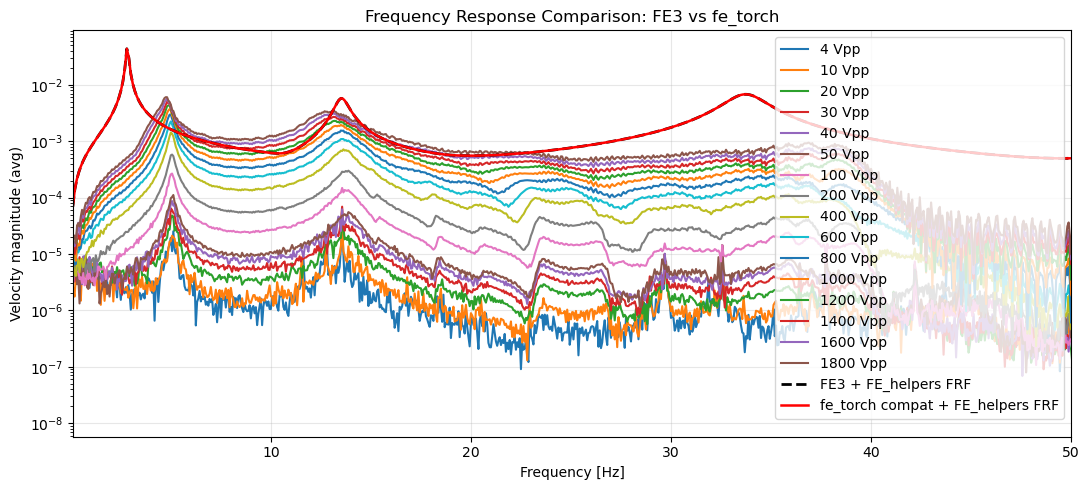

In [6]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Set your Excel file path here
excel_path = Path("./MFC1_9-28_2025.xlsx")

if not excel_path.exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path.resolve()}")

xls = pd.ExcelFile(excel_path)
plt.figure(figsize=(11, 5))

for sheet_name in xls.sheet_names:
    # Read first two columns only: frequency (col 1), velocity (col 2)
    df = pd.read_excel(excel_path, sheet_name=sheet_name, usecols=[0, 1])

    # Coerce non-numeric values (headers/empty rows) to NaN and drop them
    freq = pd.to_numeric(df.iloc[:, 0], errors="coerce")
    vel = pd.to_numeric(df.iloc[:, 1], errors="coerce")
    valid = freq.notna() & vel.notna()

    if valid.any():
        plt.semilogy(freq[valid], vel[valid], lw=1.5, label=sheet_name)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Velocity")
plt.title(f"Frequency vs Velocity from all sheets\n{excel_path.name}")
plt.grid(True, alpha=0.3)
plt.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()

plt.semilogy(freq_fd, vel_fd_fe3, 'k--', lw=2.0, label='FE3 + FE_helpers FRF')
plt.semilogy(freq_fd, vel_fd_torch, 'r-', lw=1.8, label='fe_torch compat + FE_helpers FRF')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity magnitude (avg)')
plt.xlim([f0, f1])
plt.grid(True, alpha=0.3)
plt.legend()
plt.title('Frequency Response Comparison: FE3 vs fe_torch')
plt.tight_layout()
plt.show()

Using experimental sheet: 1800 Vpp
Experimental resonance targets [Hz]: [ 4.75  13.125]


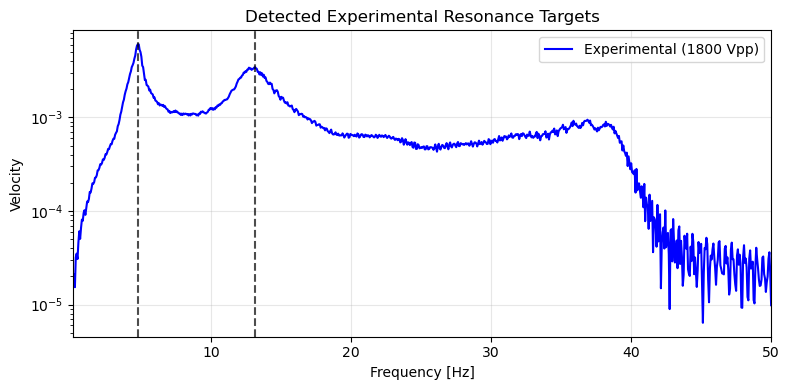

In [15]:
# ------------------------------------------------------------
# Extract first two experimental resonance targets
# ------------------------------------------------------------
from scipy.signal import find_peaks

excel_path = Path("./MFC1_9-28_2025.xlsx")
if not excel_path.exists():
    raise FileNotFoundError(f"Excel file not found: {excel_path.resolve()}")

xls_fit = pd.ExcelFile(excel_path)
preferred_sheet = "1800 Vpp" if "1800 Vpp" in xls_fit.sheet_names else xls_fit.sheet_names[-1]
df_fit = pd.read_excel(excel_path, sheet_name=preferred_sheet, usecols=[0, 1])

f_exp_all = pd.to_numeric(df_fit.iloc[:, 0], errors="coerce").to_numpy()
v_exp_all = pd.to_numeric(df_fit.iloc[:, 1], errors="coerce").to_numpy()
mask_valid = np.isfinite(f_exp_all) & np.isfinite(v_exp_all)
f_exp_all = f_exp_all[mask_valid]
v_exp_all = v_exp_all[mask_valid]

mask_band = (f_exp_all >= f0) & (f_exp_all <= f1)
f_band = f_exp_all[mask_band]
v_band = v_exp_all[mask_band]
if len(f_band) < 10:
    raise RuntimeError("Not enough experimental points in [f0, f1] band.")

peaks, _ = find_peaks(v_band, distance=20)
if len(peaks) < 2:
    raise RuntimeError("Could not detect at least two peaks in experimental curve.")

# Two highest-amplitude peaks, then sorted by frequency
peak_top2 = peaks[np.argsort(v_band[peaks])[-2:]]
f_exp_targets = np.sort(f_band[peak_top2])

print(f"Using experimental sheet: {preferred_sheet}")
print(f"Experimental resonance targets [Hz]: {f_exp_targets}")

# Quick visual confirmation
plt.figure(figsize=(8, 4))
plt.semilogy(f_band, v_band, 'b-', lw=1.5, label=f'Experimental ({preferred_sheet})')
for fx in f_exp_targets:
    plt.axvline(fx, color='k', ls='--', alpha=0.7)
plt.xlim([f0, f1])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Velocity')
plt.title('Detected Experimental Resonance Targets')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ------------------------------------------------------------
# Sensitivity study: what controls mode spacing (f2 - f1)
# Includes:
#   1) Material/section parameters in tp
#   2) Segment boundary locations x_starts (finite-diff, monotonic-preserving)
# ------------------------------------------------------------
import pandas as pd

if 'f_exp_targets' not in globals():
    raise RuntimeError('Run the resonance target extraction cell first.')

gap_exp = float(abs(f_exp_targets[1] - f_exp_targets[0]))

# -------------------------------
# Part A: tp-parameter sensitivities
# -------------------------------
candidate_names = [
    'hp', 'hs', 'b', 'E_s', 's11', 'rho_s', 'rho_p', 'd31', 'eps_r'
]
base_vals = {n: getattr(tp, n).detach().clone() for n in candidate_names}

def model_spacing_and_error(fe_model):
    f2 = fe_model(n_modes=2)['freq'][:2]
    gap_model = torch.abs(f2[1] - f2[0])
    J_gap = (gap_model - gap_exp) ** 2
    return f2, gap_model, J_gap

# Autograd on tp parameters
for p in tp.parameters():
    p.requires_grad_(False)
for n in candidate_names:
    getattr(tp, n).requires_grad_(True)

tp.zero_grad()
f2_base, gap_base, J_base = model_spacing_and_error(fe)
J_base.backward(retain_graph=True)
grad_J = {
    n: (getattr(tp, n).grad.item() if getattr(tp, n).grad is not None else 0.0)
    for n in candidate_names
}

tp.zero_grad()
gap_base.backward()
grad_gap = {
    n: (getattr(tp, n).grad.item() if getattr(tp, n).grad is not None else 0.0)
    for n in candidate_names
}

rows_tp = []
for n in candidate_names:
    p0 = base_vals[n].item()
    rel_step = 0.01 * abs(p0) if abs(p0) > 0 else 1e-12
    rows_tp.append({
        'group': 'tp_param',
        'name': n,
        'base_value': p0,
        'autograd_gap_effect_1pct': abs(grad_gap[n] * rel_step),
        'autograd_Jgap_effect_1pct': abs(grad_J[n] * rel_step),
    })

# Finite-diff check on tp parameters
fd_tp = []
with torch.no_grad():
    for n in candidate_names:
        p = getattr(tp, n)
        p0 = base_vals[n].item()
        dp = 0.01 * abs(p0) if abs(p0) > 0 else 1e-12

        p.fill_(p0 + dp)
        _, gap_plus, J_plus = model_spacing_and_error(fe)

        p.fill_(p0 - dp)
        _, gap_minus, J_minus = model_spacing_and_error(fe)

        p.fill_(p0)

        fd_tp.append({
            'group': 'tp_param',
            'name': n,
            'fd_gap_effect_1pct': abs(gap_plus.item() - gap_minus.item()) / 2.0,
            'fd_Jgap_effect_1pct': abs(J_plus.item() - J_minus.item()) / 2.0,
        })

with torch.no_grad():
    for n in candidate_names:
        getattr(tp, n).copy_(base_vals[n])

# -------------------------------
# Part B: x_start location sensitivities
# -------------------------------
# Evaluate influence of each boundary location while preserving strict ordering.

def region_scalars_from_tp(tp_local):
    E_p_local = 1.0 / tp_local.s11.item()

    # Substrate-only
    EI_sub = tp_local.b.item() * tp_local.E_s.item() * tp_local.hs.item() ** 3 / 12.0
    rhoA_sub = tp_local.b.item() * tp_local.rho_s.item() * tp_local.hs.item()

    # Kapton stack
    EI_kap, rhoA_kap = compute_EI_and_rhoA(
        E_layers=[tp_local.E_s.item(), E_k],
        rho_layers=[tp_local.rho_s.item(), rho_k],
        h_layers=[tp_local.hs.item(), h_k],
        b_layers=[tp_local.b.item(), b_k],
    )

    # Piezo stack
    EI_pie, rhoA_pie = compute_EI_and_rhoA(
        E_layers=[tp_local.E_s.item(), E_k, E_p_local],
        rho_layers=[tp_local.rho_s.item(), rho_k, tp_local.rho_p.item()],
        h_layers=[tp_local.hs.item(), h_k, tp_local.hp.item()],
        b_layers=[tp_local.b.item(), b_k, b_p],
    )

    return {
        'substrate': {'EI': EI_sub, 'rhoA': rhoA_sub, 'h': 1e-3},
        'kapton': {'EI': EI_kap, 'rhoA': rhoA_kap, 'h': 1e-3},
        'piezo': {'EI': EI_pie, 'rhoA': rhoA_pie, 'h': 5e-3},
    }


def build_fe_for_xstarts(xstarts_new):
    region_types_local = region_scalars_from_tp(tp)
    geom_local = build_geometry_from_types(
        L=L,
        region_types=region_types_local,
        region_sequence=region_sequence,
        x_starts=xstarts_new,
        default_h=1e-3,
    )

    x_nodes_local = np.asarray(geom_local.x_nodes, dtype=float)
    x_mid_local = 0.5 * (x_nodes_local[:-1] + x_nodes_local[1:])

    labels = []
    for xm in x_mid_local:
        idx = np.searchsorted(xstarts_new, xm, side='right') - 1
        idx = int(np.clip(idx, 0, len(region_sequence) - 1))
        labels.append(region_sequence[idx])

    n_elem_local = len(geom_local.elem_EI)
    EI_vec_np = np.empty((n_elem_local,), dtype=float)
    rhoA_vec_np = np.empty((n_elem_local,), dtype=float)

    for i, lbl in enumerate(labels):
        EI_vec_np[i] = region_types_local[lbl]['EI']
        rhoA_vec_np[i] = region_types_local[lbl]['rhoA']

    EI_const = torch.tensor(EI_vec_np, dtype=tp.dtype)
    rhoA_const = torch.tensor(rhoA_vec_np, dtype=tp.dtype)

    def elem_property_fn_local(_tp_local):
        return EI_const, rhoA_const

    return PiezoBeamFE_Torch(tp, geometry=geom_local, elem_property_fn=elem_property_fn_local)


def spacing_metrics_for_xstarts(xstarts_new):
    fe_local = build_fe_for_xstarts(xstarts_new)
    f2_local = fe_local(n_modes=2)['freq'][:2].detach().cpu().numpy()
    gap_local = abs(float(f2_local[1] - f2_local[0]))
    J_local = (gap_local - gap_exp) ** 2
    return f2_local, gap_local, J_local

x0 = np.asarray(x_starts, dtype=float).copy()
min_sep = 0.5e-3
fd_x_rows = []

# Keep first boundary fixed (usually 0); perturb others with ordering-safe bounds
for i in range(1, len(x0)):
    lo = x0[i - 1] + min_sep
    hi = (x0[i + 1] - min_sep) if i < len(x0) - 1 else (L - min_sep)

    if hi <= lo:
        continue

    # 1% of local neighboring span, capped for stability
    span_i = hi - lo
    dx = min(0.01 * span_i, 0.4e-3)
    if dx <= 0:
        continue

    x_plus = x0.copy()
    x_minus = x0.copy()
    x_plus[i] = min(x0[i] + dx, hi)
    x_minus[i] = max(x0[i] - dx, lo)

    if not (np.all(np.diff(x_plus) > 0) and np.all(np.diff(x_minus) > 0)):
        continue

    _, gap_plus, J_plus = spacing_metrics_for_xstarts(x_plus)
    _, gap_minus, J_minus = spacing_metrics_for_xstarts(x_minus)

    fd_x_rows.append({
        'group': 'x_start',
        'name': f'x_start[{i}]',
        'base_value': x0[i],
        'fd_gap_effect_step': abs(gap_plus - gap_minus) / 2.0,
        'fd_Jgap_effect_step': abs(J_plus - J_minus) / 2.0,
        'step_um': dx * 1e6,
    })

# -------------------------------
# Merge + ranking
# -------------------------------
df_tp = pd.DataFrame(rows_tp).merge(pd.DataFrame(fd_tp), on=['group', 'name'], how='left')
if len(fd_x_rows) > 0:
    df_x = pd.DataFrame(fd_x_rows)
else:
    df_x = pd.DataFrame(columns=['group', 'name', 'base_value', 'fd_gap_effect_step', 'fd_Jgap_effect_step', 'step_um'])

print(f'Experimental spacing |f2-f1| [Hz]: {gap_exp:.6f}')
print(f'Current model f1,f2 [Hz]: {f2_base.detach().cpu().numpy()}')
print(f'Current model spacing [Hz]: {gap_base.item():.6f}')
print(f'Current spacing error objective J_gap: {J_base.item():.6e}')

print('\nTop tp parameters controlling spacing |f2-f1| (finite-diff 1% effect):')
display(df_tp.sort_values('fd_gap_effect_1pct', ascending=False)[['name', 'fd_gap_effect_1pct']].head(6))

print('\nTop tp parameters controlling spacing error J_gap (finite-diff 1% effect):')
display(df_tp.sort_values('fd_Jgap_effect_1pct', ascending=False)[['name', 'fd_Jgap_effect_1pct']].head(6))

if len(df_x) > 0:
    print('\nTop x_start locations controlling spacing |f2-f1| (finite-diff local step):')
    display(df_x.sort_values('fd_gap_effect_step', ascending=False)[['name', 'fd_gap_effect_step', 'step_um']].head(8))

    print('\nTop x_start locations controlling spacing error J_gap (finite-diff local step):')
    display(df_x.sort_values('fd_Jgap_effect_step', ascending=False)[['name', 'fd_Jgap_effect_step', 'step_um']].head(8))

print('\nFull tp sensitivity table:')
display(df_tp)

if len(df_x) > 0:
    print('\nFull x_start sensitivity table:')
    display(df_x)


Experimental spacing |f2-f1| [Hz]: 8.375000
Current model f1,f2 [Hz]: [ 2.82846226 13.52869723]
Current model spacing [Hz]: 10.700235
Current spacing error objective J_gap: 5.406718e+00

Top tp parameters controlling spacing |f2-f1| (finite-diff 1% effect):


,name,fd_gap_effect_1pct
1,hs,0.094542
5,rho_s,0.041106
3,E_s,0.039805
6,rho_p,0.007111
4,s11,0.005945
2,b,0.001512



Top tp parameters controlling spacing error J_gap (finite-diff 1% effect):


,name,fd_Jgap_effect_1pct
1,hs,0.439675
5,rho_s,0.191188
3,E_s,0.185112
6,rho_p,0.033073
4,s11,0.027650
2,b,0.007033



Top x_start locations controlling spacing |f2-f1| (finite-diff local step):


...

,name,fd_Jgap_effect_step,step_um
0,x_start[1],0.107533,315.0
18,x_start[19],0.091406,400.0
16,x_start[17],0.049717,315.0
17,x_start[18],0.044700,315.0
13,x_start[14],0.044386,315.0
5,x_start[6],0.022934,315.0
12,x_start[13],0.020941,315.0
8,x_start[9],0.018489,315.0



Full tp sensitivity table:


,group,name,base_value,autograd_gap_effect_1pct,autograd_Jgap_effect_1pct,fd_gap_effect_1pct,fd_Jgap_effect_1pct
0,tp_param,hp,1.200000e-04,0.000308,0.001434,0.000323,0.001502
1,tp_param,hs,5.000000e-04,0.094676,0.440286,0.094542,0.439675
2,tp_param,b,1.000000e-01,0.001460,0.006791,0.001512,0.007033
3,tp_param,E_s,3.000000e+09,0.039753,0.184868,0.039805,0.185112
4,tp_param,s11,3.225806e-11,0.006006,0.027932,0.005945,0.027650
5,tp_param,rho_s,1.190000e+03,0.041213,0.191659,0.041106,0.191188
6,tp_param,rho_p,7.800000e+03,0.007160,0.033297,0.007111,0.033073
7,tp_param,d31,-1.480000e-10,0.000000,0.000000,0.000000,0.000000
8,tp_param,eps_r,1.700000e+03,0.000000,0.000000,0.000000,0.000000



Full x_start sensitivity table:


,group,name,base_value,fd_gap_effect_step,fd_Jgap_effect_step,step_um
0,x_start,x_start[1],0.0045,0.023118,0.107533,315.0
1,x_start,x_start[2],0.0325,0.003633,0.016894,315.0
2,x_start,x_start[3],0.0370,0.000530,0.002466,65.0
3,x_start,x_start[4],0.0400,0.000202,0.000939,65.0
4,x_start,x_start[5],0.0445,0.000923,0.004292,315.0
5,x_start,x_start[6],0.0725,0.004931,0.022934,315.0
6,x_start,x_start[7],0.0770,0.001240,0.005768,65.0
7,x_start,x_start[8],0.0800,0.001261,0.005862,65.0
8,x_start,x_start[9],0.0845,0.003975,0.018489,315.0
9,x_start,x_start[10],0.1125,0.001674,0.007783,315.0
